# ElideDB — every query style, from Python

A **Parquet-only, timestamp-first multimodal store**. Every table — sensor rows,
the video frame index, embeddings, cluster centroids — is plain Parquet under a
Delta-style transaction log. No custom binary formats; any engine that reads
Parquet reads this database.

This notebook runs against two lakes built from real data:
- `lake/oxford` — Oxford RobotCar sample (6 cameras, GPS/INS, lidar)
- `lake/lab` — 4-sensor lab capture (8× 4K cameras, 4× 16-ch audio, telemetry)

Query styles covered: **inventory · window · frame decode · alignment ·
projection · time travel · SQL (DuckDB) · semantic text search · clip
similarity · ingest → embed → retrieve on brand-new data.**

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "python"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from elidedb import Store

ox  = Store.open("../lake/oxford")
lab = Store.open("../lake/lab")
OXB  = 1418381153300352000   # oxford corpus start (ns, Dec 2014 — real UTC)
LABB = 1775240185000000000   # lab capture anchor (ns)
def T(base, sec): return base + int(sec * 1e9)

pd.DataFrame(ox.describe())[["table","kind","rows","bytes","files","version"]]

,table,kind,rows,bytes,files,version
0,centroids,centroids,2,13134,1,1
1,embeddings,embeddings,120,819593,1,1
2,frames,frame_index,1443,40787,6,6
3,gps,timeseries,12636,1013296,1,1
4,ins,timeseries,126361,11448815,1,1
5,ldmrs,timeseries,238,8357,1,1
6,lms_front,timeseries,950,19490,1,1
7,lms_rear,timeseries,951,19043,1,1


## 1 · Window query — the core read

`store.window(t0, t1)` returns every requested table filtered to the time
window. File-level pruning happens from the transaction log's zone maps;
row-group pruning happens from Parquet's own statistics; the stats object
reports exactly what was touched.

In [2]:
w, stats = ox.window(T(OXB, 651), T(OXB, 653), tables=["frames", "gps", "ins"])
print(stats)
w["frames"], w["ins"].to_pandas().head(3)[["ts","latitude","longitude","velocity_north","yaw"]]

<8/8 files, 6,835,215 B touched of 12,502,898 B (45.331% elided), 272 rows, 29.0 ms>


(<FrameSet 162 frames, streams=['mono/left', 'mono/rear', 'mono/right', 'stereo/centre', 'stereo/left', 'stereo/right']>,
                     ts   latitude  longitude  velocity_north       yaw
 0  1418381804319212000  51.754584  -1.255366        1.933165  1.242403
 1  1418381804339212000  51.754584  -1.255364        1.941785  1.241621
 2  1418381804359212000  51.754585  -1.255362        1.949518  1.240901)

### Decoding frames

The `frames` table stores byte ranges into the untouched source media —
`decode()` preads exactly those packets (late materialization: pixels are
produced last, after all pruning).

decoded 8 frames, read 2,101,191 bytes


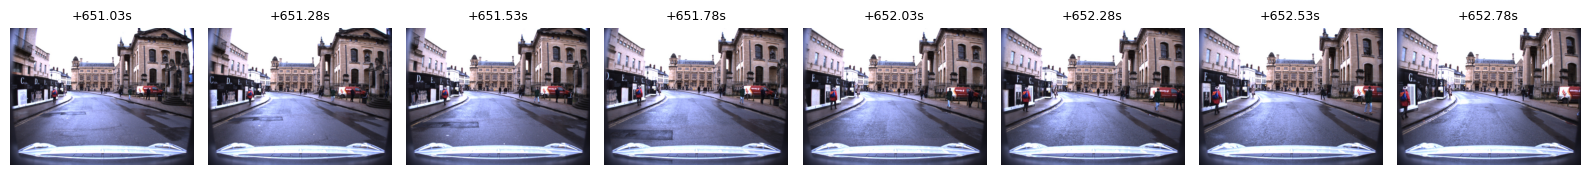

In [3]:
frames = w["frames"].decode(stream="stereo/centre", width=480, stride=4)
print(f"decoded {len(frames)} frames, read {w['frames'].last_bytes_read:,} bytes")
fig, axes = plt.subplots(1, len(frames), figsize=(16, 3.2))
for ax, (ts, img) in zip(axes, frames):
    ax.imshow(img); ax.set_title(f"+{(ts-OXB)/1e9:.2f}s", fontsize=9); ax.axis("off")
plt.tight_layout()

## 2 · Query-time alignment

Storage never commits to a rate: `aligned()` resamples every numeric column
onto the caller's timeline (nearest or linear). Here INS velocity and a camera
strip share one clock.

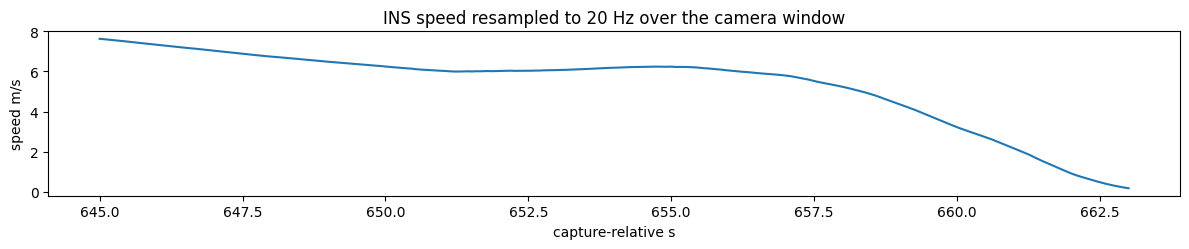

In [4]:
al, _ = ox.aligned(T(OXB, 645), T(OXB, 663), rate_hz=20, tables=["ins"], interp="linear")
tl = (al["timeline_ns"] - OXB) / 1e9
speed = np.hypot(al["ins"]["velocity_north"], al["ins"]["velocity_east"])
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.plot(tl, speed, lw=1.5); ax.set_ylabel("speed m/s"); ax.set_xlabel("capture-relative s")
ax.set_title("INS speed resampled to 20 Hz over the camera window"); plt.tight_layout()

## 3 · Column projection + elision

Ask for two columns of a 14.16M-row, 17-column audio table: only the projected
column chunks of the surviving row groups are touched.

<1/1 files, 1,588,674 B touched of 285,948,549 B (99.444% elided), 96,000 rows, 0.0 ms>


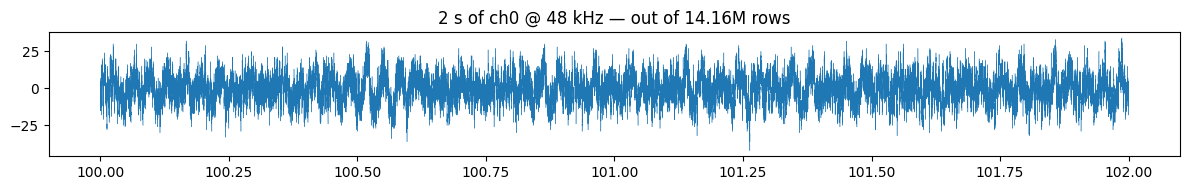

In [5]:
t = lab.table("sensor_108_audio")
from elidedb.store import QueryStats
qs = QueryStats()
audio = t.scan(T(LABB, 100), T(LABB, 102), columns=["ts", "ch0"], stats=qs)
print(qs)
wave = audio.column("ch0").to_numpy()
fig, ax = plt.subplots(figsize=(12, 2))
ax.plot((audio.column("ts").to_numpy() - LABB)/1e9, wave, lw=0.3)
ax.set_title("2 s of ch0 @ 48 kHz — out of 14.16M rows"); plt.tight_layout()

## 4 · Time travel

A table is the fold of its log. Reading at an older version is free — old
files are immutable, the log just stops folding earlier.

In [6]:
hist = pd.DataFrame(lab.table("frames").history())
print(f"frames table now: v{lab.table('frames').state().rows and lab.table('frames').state().version}, "
      f"{lab.table('frames').state().rows:,} rows")
print(f"frames table @v10: {lab.table('frames').state(10).rows:,} rows")
hist.tail(4)

frames table now: v54, 45,449 rows
frames table @v10: 9,465 rows


,version,ts_utc,op,added_files,added_rows,meta
50,51,2026-07-18T04:02:06Z,append,1,810,{'migrated_from': 'sfi/Sensor_108_cam2_seg4.sfi'}
51,52,2026-07-18T04:02:06Z,append,1,796,{'migrated_from': 'sfi/Sensor_108_cam2_seg5.sfi'}
52,53,2026-07-18T04:02:06Z,append,1,793,{'migrated_from': 'sfi/Sensor_108_cam2_seg6.sfi'}
53,54,2026-07-18T04:02:06Z,append,1,648,{'migrated_from': 'sfi/Sensor_108_cam2_seg7.sfi'}


## 5 · SQL — the lakehouse dividend

Because the store is plain Parquet, DuckDB queries it directly. Table names in
SQL are store table names; nothing is exported or copied.

In [7]:
ox.sql('''
  SELECT round(avg(sqrt(velocity_north^2 + velocity_east^2)), 2) AS avg_speed_ms,
         round(max(sqrt(velocity_north^2 + velocity_east^2)), 2) AS max_speed_ms,
         count(*) AS ins_rows,
         round((max(ts) - min(ts)) / 1e9) AS span_s
  FROM ins''')

,avg_speed_ms,max_speed_ms,ins_rows,span_s
0,3.62,12.13,126361,2527.0


In [8]:
# lidar activity vs vehicle speed, joined on 1-second buckets — plain SQL
ox.sql('''
  WITH l AS (SELECT ts // 1000000000 AS sec, avg(mean_range) AS lidar_range
             FROM lms_front GROUP BY 1),
       v AS (SELECT ts // 1000000000 AS sec,
             avg(sqrt(velocity_north^2 + velocity_east^2)) AS speed FROM ins GROUP BY 1)
  SELECT l.sec - min(l.sec) OVER () AS t_s, round(lidar_range,1) AS lidar_range_m,
         round(speed,2) AS speed_ms
  FROM l JOIN v USING (sec) ORDER BY 1 LIMIT 8''')

,t_s,lidar_range_m,speed_ms
0,0,214.1,7.56
1,1,213.5,7.27
2,2,207.1,6.97
3,3,196.9,6.69
4,4,200.8,6.44
5,5,213.0,6.20
6,6,214.8,6.02
7,7,209.0,6.03


## 6 · Semantic text search

Text → SigLIP vector (local, MLX) → two-stage rank: centroid prune (learned-cell
IVF), exact cosine over survivors. Hits are `(stream, t0, t1)` — time, which
feeds straight back into `window()` to fetch the actual clip.

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

{'scanned': 120, 'total': 120, 'clusters_probed': 2, 'clusters_total': 2}


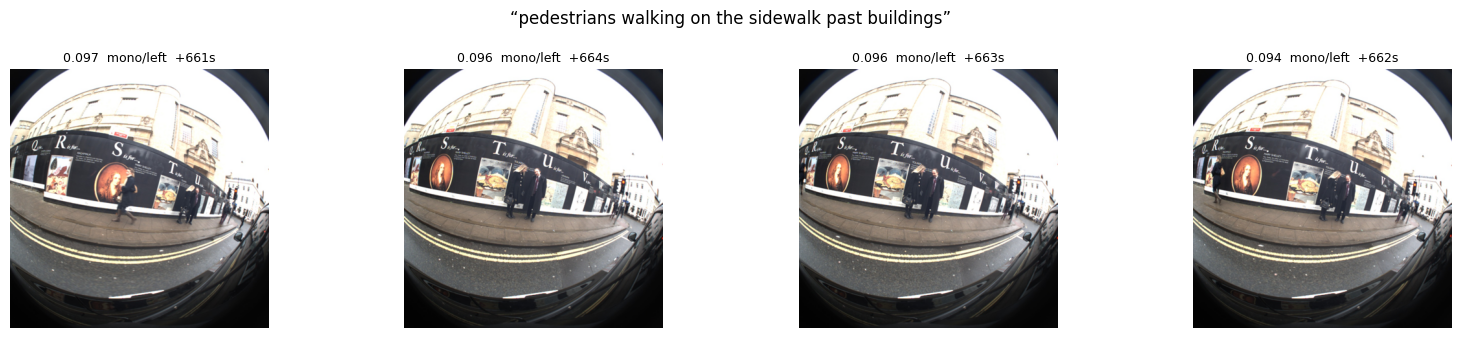

In [9]:
hits, hstats = ox.search_text("pedestrians walking on the sidewalk past buildings", k=4)
print(hstats)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, h in zip(axes, hits):
    win, _ = ox.window(h["t0"], h["t1"], tables=["frames"])
    ts, img = win["frames"].decode(stream=h["stream"], width=400, limit=1)[0]
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{h['score']:.3f}  {h['stream']}  +{(h['t0']-OXB)/1e9:.0f}s", fontsize=9)
plt.suptitle("“pedestrians walking on the sidewalk past buildings”"); plt.tight_layout()

{'scanned': 321, 'total': 1194, 'clusters_probed': 3, 'clusters_total': 12}


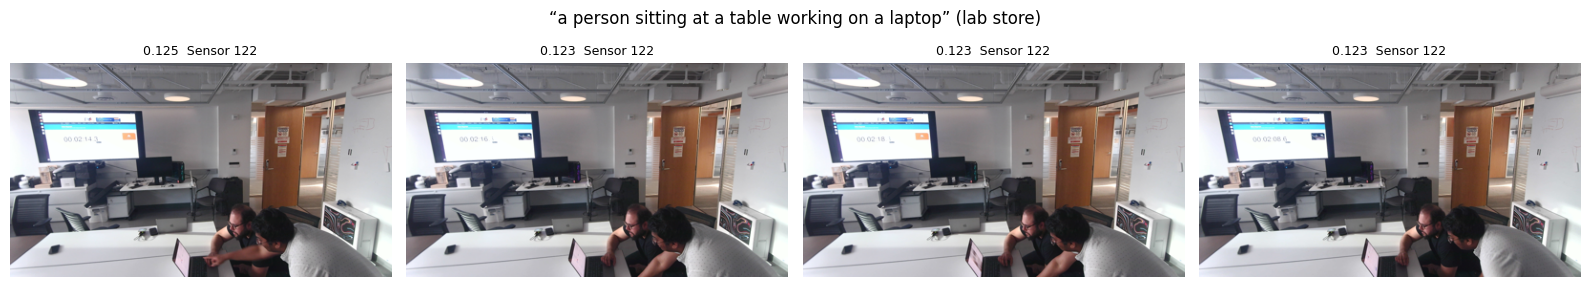

In [10]:
hits, hstats = lab.search_text("a person sitting at a table working on a laptop", k=4, nprobe=3)
print(hstats)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.0))
for ax, h in zip(axes, hits):
    win, _ = lab.window(h["t0"], h["t1"], tables=["frames"])
    dec = win["frames"].decode(stream=h["stream"], width=400, limit=1)
    if dec:
        ax.imshow(np.rot90(dec[0][1], 2))  # lab cameras are mounted rotated
    ax.axis("off"); ax.set_title(f"{h['score']:.3f}  {h['stream'].split('/')[0]}", fontsize=9)
plt.suptitle("“a person sitting at a table working on a laptop” (lab store)"); plt.tight_layout()

## 7 · Clip similarity (query by example)

Mean-pool the embedded windows overlapping a probe clip, rank everything else.
On the Oxford store this finds the *same street moment seen by sibling
cameras*.

{'scanned': 60, 'total': 120, 'clusters_probed': 1, 'clusters_total': 2}


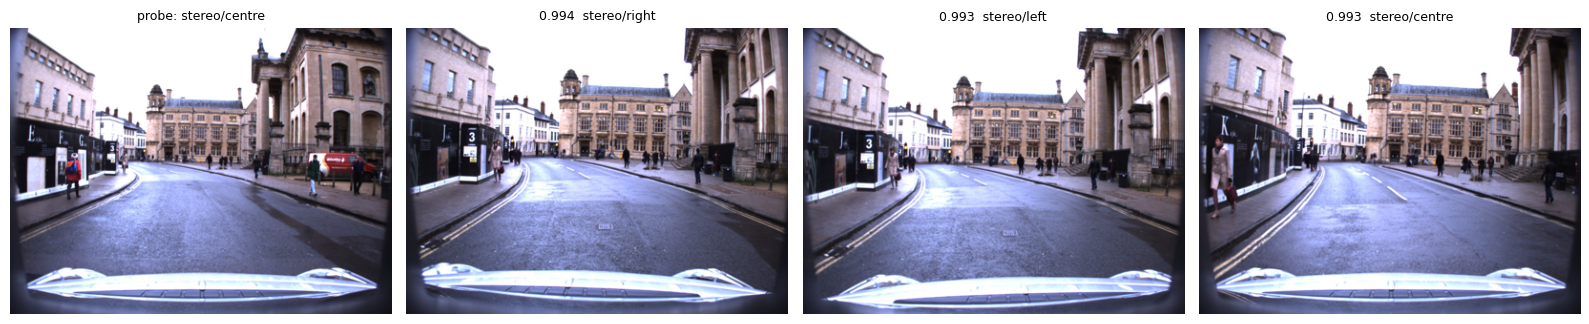

In [11]:
probe_t0, probe_t1 = T(OXB, 652), T(OXB, 654)
hits, hstats = ox.search_clip("stereo/centre", probe_t0, probe_t1, k=3, nprobe=1)
print(hstats)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
win, _ = ox.window(probe_t0, probe_t1, tables=["frames"])
ts, img = win["frames"].decode(stream="stereo/centre", width=400, limit=1)[0]
axes[0].imshow(img); axes[0].axis("off"); axes[0].set_title("probe: stereo/centre", fontsize=9)
for ax, h in zip(axes[1:], hits):
    win, _ = ox.window(h["t0"], h["t1"], tables=["frames"])
    ts, img = win["frames"].decode(stream=h["stream"], width=400, limit=1)[0]
    ax.imshow(img); ax.axis("off"); ax.set_title(f"{h['score']:.3f}  {h['stream']}", fontsize=9)
plt.tight_layout()

## 8 · The full loop on NEW data: ingest → embed → retrieve

Any timestamped data goes in. Below: a brand-new store gets (a) a sensor
stream from a DataFrame, (b) a video indexed by packet scan, (c) embeddings,
(d) a semantic query — the complete lifecycle in a few lines.

In [12]:
import shutil, pathlib
scratch = pathlib.Path("/tmp/streetdex_fresh"); shutil.rmtree(scratch, ignore_errors=True)
fresh = Store.create(scratch, "fresh-demo")

# (a) any timestamped rows — note ts_unit conversion
fresh.ingest_rows("thermometer",
    pd.DataFrame({"t": OXB//10**9 + np.arange(600), "temp_c": 9 + np.random.randn(600)*.2}),
    ts_column="t", ts_unit="s")

# (b) any video + per-frame timestamps (ns): here one Oxford camera pack
ts_ns = [int(l) for l in open("../store_oxford/packed/mono_left.ts")]
fresh.ingest_video("frames", "../store_oxford/packed/mono_left.avi",
                   timestamps_ns=ts_ns, stream="cam")
pd.DataFrame(fresh.describe())[["table","kind","rows","version"]]

,table,kind,rows,version
0,frames,frame_index,210,1
1,thermometer,timeseries,600,1


In [13]:
# (c) embed 2-second windows of every video stream in the store
print(fresh.embed_windows(window_s=2.0, frames_per_window=1))
from elidedb import cluster
print(cluster(fresh, min_cluster_size=5))

{'windows': 10, 'dim': 1152, 'version': 1, 'seconds': 1.6}
{'clusters': 0, 'noise': 10, 'windows': 10}


{'scanned': 10, 'total': 10, 'clusters_probed': 0, 'clusters_total': 0}


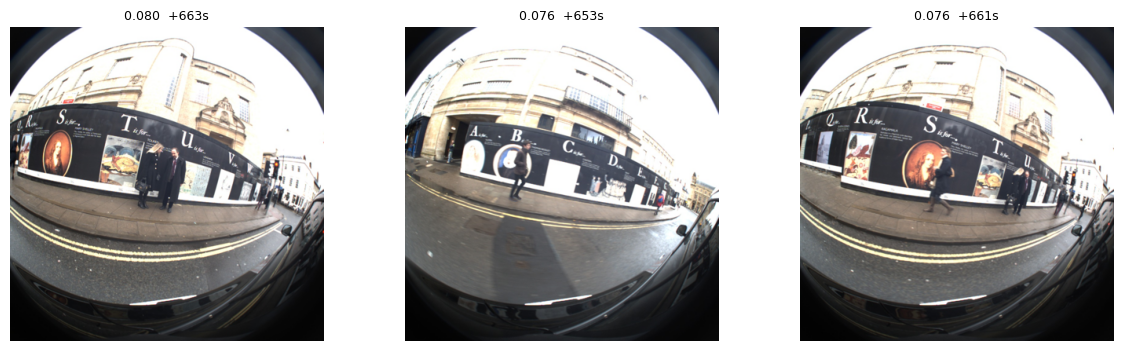

In [14]:
# (d) retrieve — same API as the big stores
hits, hstats = fresh.search_text("a person walking past a black fence", k=3)
print(hstats)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, h in zip(axes, hits):
    win, _ = fresh.window(h["t0"], h["t1"], tables=["frames"])
    dec = win["frames"].decode(width=400, limit=1)
    if dec: ax.imshow(dec[0][1])
    ax.axis("off"); ax.set_title(f"{h['score']:.3f}  +{(h['t0']-OXB)/1e9:.0f}s", fontsize=9)
plt.tight_layout()

## Where to go next

- `python/elidedb/` — the whole engine (~700 lines: log, store, video, embeddings)
- `docs/GETTING_STARTED.md` + `docs/API.md` — use it with YOUR data
- **ElideDB Desk** — `elidedb desk` (or the macOS app in `desk/`)